# Predicción de ocurrencia de infarto cerebral 

<a id="indice"></a>
# Índice del proyecto

## Tabla de contenidos

- [1. Análisis exploratorio de datos (EDA)](#eda)
  - [1.1 Análisis univariante](#analisis-univariante)
    - [Variables identificadoras y demográficas](#variables-demograficas)
    - [Variables clínicas](#variables-clinicas)
    - [Variables socioeconómicas y estilo de vida](#variables-socioeconomicas)
    - [Variable objetivo (`stroke`)](#variable-objetivo)
  - [1.2 Análisis Bivariante](#análisis-bivariante)

- [2. Limpieza y transformación de los datos](#limpieza)
---

<a id="eda"></a>
# 1. Análisis Exploratorio de Datos (EDA)

In [1]:
# importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# lectura del csv
df = pd.read_csv ("stroke.csv")

In [3]:
# muestra de las 5 primeras filas
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# dimensiones del dataframe 
df.shape

(5110, 12)

El dataframe tiene 12 columnas con las variables de 5110 individuos. 

In [5]:
# información sobre las variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


---

<a id="analisis-univariante"></a>
## 1.1 Análisis Univariante

<a id="variables-demograficas"></a>
#### <a id="seccion-1-1-1"></a>Variables identificadoras y demográficas

<a id="variables-demograficas"></a>
* id

In [77]:
# Devuelve True si hay al menos un ID duplicado, False si todos son únicos
df["id"].duplicated().any()

np.False_

La columna id contiene valores únicos para cada paciente, por lo que no aporta valor predictivo y será eliminada en la fase de preparación de datos.

* age

In [78]:
# Resumen estadístico de la edad
df["age"].describe()

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

In [ ]:
# Redondea al entero más cercano y convierte el tipo de dato a entero (int64)
df["age"] = df["age"].round().astype(int)

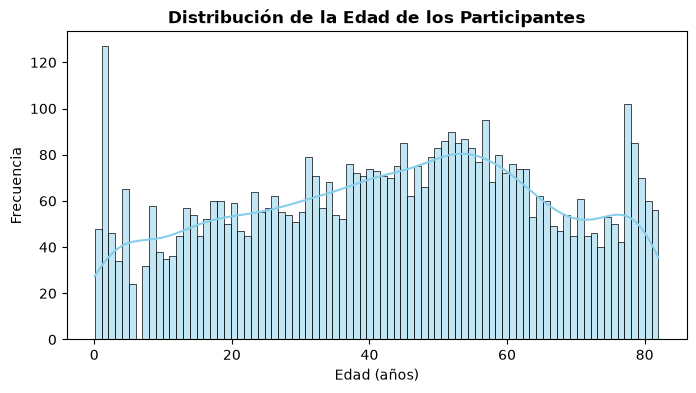

In [79]:
# gráfico para entender la distribución de la edad en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], bins=83, kde=True, color="skyblue")
plt.title("Distribución de la Edad de los Participantes", fontsize=12, fontweight="bold")
plt.xlabel("Edad (años)", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

In [80]:
# Contar número de personas con edad menor a 18
menores_18 = (df["age"] < 18).sum()
porcentaje_menores = (df["age"] < 18).mean() * 100

print(f"Número de menores de 18 años: {menores_18}")
print(f"Porcentaje sobre el total: {porcentaje_menores:.2f}%")

Número de menores de 18 años: 856
Porcentaje sobre el total: 16.75%


In [81]:
# Ver cuántos casos de ictus hay entre los menores de 18 años
df[df["age"] < 18]["stroke"].value_counts()

stroke
0    854
1      2
Name: count, dtype: int64

In [82]:
# 1. Crear una copia filtrada solo con adultos (18 años o más)
df_adultos = df[df["age"] >= 18].copy()

# 2. Verificar las dimensiones de ambos DataFrames
print(f"Filas en el DataFrame original (con menores): {df.shape[0]}")
print(f"Filas en el DataFrame filtrado (solo adultos): {df_adultos.shape[0]}")
print(f"Menores eliminados: {len(df) - len(df_adultos)}")

Filas en el DataFrame original (con menores): 5110
Filas en el DataFrame filtrado (solo adultos): 4254
Menores eliminados: 856


De las 856 personas menores de 18 años, únicamente 2 casos presentan registro de ictus (frente a los 247 casos en adultos). Esta baja prevalencia, sumada a la diferencia etiología del accidente cerebrovascular en pediatría, respalda la decisión metodológica de acotar el estudio a la población adulta (>18 años) para comparar los resultados con el modelo de referencia (Dritsas & Trigka, 2022).
El filtrado de pacientes menores de 18 años (age >= 18) se realiza al inicio del estudio y no en la fase de limpieza posterior para asegurar que todo el Análisis Exploratorio de Datos (EDA) responda de forma coherente al problema clínico abordado. De este modo, las métricas descriptivas, tablas de frecuencia y relaciones bivariantes se estudian desde el primer momento exclusivamente sobre la muestra representativa de adultos de riesgo.

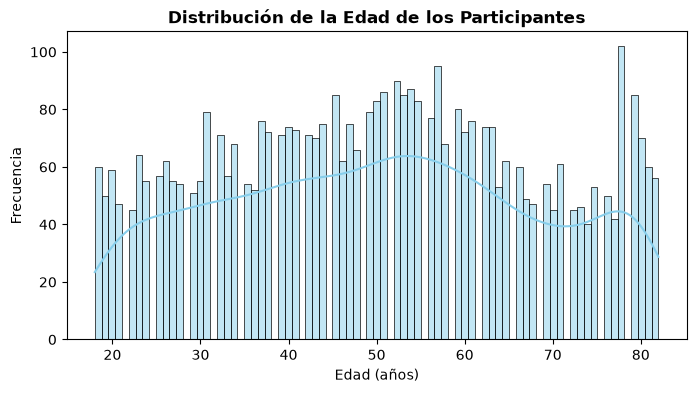

In [83]:
#gráfico para entender la distribución de la edad de los adultos en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df_adultos["age"], bins=83, kde=True, color="skyblue")
plt.title("Distribución de la Edad de los Participantes", fontsize=12, fontweight="bold")
plt.xlabel("Edad (años)", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

Histograma: Distribución de la edad de los participantes adultos
Tras acotar la muestra a la población adulta, el gráfico muestra la distribución de frecuencia por cada año de edad individual (de 18 a 82 años) La muestra cubre de forma continua el espectro adulto desde los 18 hasta los 82 años.   Se observa una mayor densidad de participantes en la franja media-avanzada, concretamente entre los 50 y 60 años, donde se alcanza la cúspide de la curva de estimación de densidad. Destaca un pico pronunciado de frecuencia alrededor de los 78 y 80 años (superando los 100 registros para una sola edad). Esto sugiere un posible sesgo de redondeo o agrupación en la recogida original de datos en pacientes octogenarios.

In [84]:
# 1. Definir los cortes y etiquetas para los rangos de edad
cortes = [18, 25, 35, 45, 55, 65, 75, 83]
etiquetas = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']

# 2. Crear la nueva variable de rango de edad en el DataFrame filtrado
df_adultos['age_group'] = pd.cut(df_adultos['age'], bins=cortes, labels=etiquetas, right=False)

# 3. Mostrar tabla de frecuencias absolutas y relativas
tabla_edades = pd.DataFrame({
    'Total Participantes': df_adultos['age_group'].value_counts(sort=False),
    'Porcentaje (%)': (df_adultos['age_group'].value_counts(normalize=True, sort=False) * 100).round(2),
    'Casos de Ictus': df_adultos.groupby('age_group')['stroke'].sum(),
    'Tasa Ictus (%)': (df_adultos.groupby('age_group')['stroke'].mean() * 100).round(2)
})

tabla_edades

,Total Participantes,Porcentaje (%),Casos de Ictus,Tasa Ictus (%)
age_group,,,,
18-24,380,8.93,0,0.00
25-34,609,14.32,1,0.16
35-44,688,16.17,7,1.02
45-54,798,18.76,27,3.38
55-64,752,17.68,53,7.05
65-74,509,11.97,57,11.20
75+,518,12.18,102,19.69


Agrupamiento por rangos de edad:El volumen de participantes por grupo alcanza su máximo en la franja de 45 a 54 años (18.76 %). El grupo de edad más avanzada (75+ años) representa un 12.18\% del total (518 individuos), descartando un sesgo de sobrerepresentación en octogenarios.   La tasa de incidencia de ictus muestra un crecimiento posiblemente correlacionado con la edad:   muy baja en menores de 45 años (<1%).   Se sitúa en el 7.05\% entre los 55 y 64 años.   Alcanza el 19.69\% en el grupo de 75+ años, donde prácticamente 1 de cada 5 personas ha sufrido un ictus.   Conclusión: Concentrar la mayoría de los casos positivos de ictus (102 de los 247 totales) en el grupo de mayor edad confirma la coherencia biológica y clínica del dataset para el posterior modelado predictivo.   

* gender

In [85]:
# Muestra un array con las respuestas únicas
df_adultos["gender"].unique()

<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

In [86]:
# Frecuencias absolutas y relativas para 'gender'
frecuencias_gender = df_adultos["gender"].value_counts()
porcentajes_gender = df_adultos["gender"].value_counts(normalize=True) * 100

resumen_gender = pd.DataFrame({
    'Frecuencia': frecuencias_gender,
    'Porcentaje (%)': porcentajes_gender.round(2)
})

resumen_gender

,Frecuencia,Porcentaje (%)
gender,,
Female,2576,60.55
Male,1677,39.42
Other,1,0.02


<a id="variables-clinicas"></a>
#### <a id="seccion-1-1-2"></a>Variables Clínicas

* hypertension

In [87]:
# comprobar categorías
df_adultos["hypertension"].unique()

array([0, 1])

In [88]:

# Tabla de frecuencias absolutas y relativas
tabla_hypertension = pd.DataFrame({
    "Participantes": df_adultos["hypertension"].value_counts(),
    "Porcentaje (%)": (df_adultos["hypertension"].value_counts(normalize=True) * 100).round(2)
})

tabla_hypertension

,Participantes,Porcentaje (%)
hypertension,,
0,3757,88.32
1,497,11.68


* heart_disease

In [89]:
# valores único
df_adultos["heart_disease"].unique()

array([1, 0])

In [90]:
# tabla de frecuencias
tabla_heart_disease = pd.DataFrame({
    "Participantes adultos": df_adultos["heart_disease"].value_counts(),
    "Porcentaje (%)": (df_adultos["heart_disease"].value_counts(normalize=True) * 100).round(2)
})

tabla_heart_disease

,Participantes adultos,Porcentaje (%)
heart_disease,,
0,3979,93.54
1,275,6.46


* avg_glucose_level

In [91]:
df_adultos["avg_glucose_level"] = df_adultos["avg_glucose_level"].round()

In [92]:
df_adultos["avg_glucose_level"].describe()

count    4254.000000
mean      108.511519
std        47.777895
min        55.000000
25%        77.000000
50%        92.000000
75%       116.000000
max       272.000000
Name: avg_glucose_level, dtype: float64

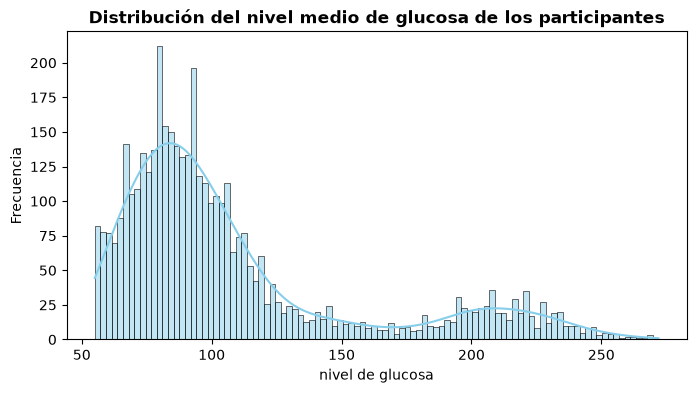

In [93]:
#gráfico para entender la distribución de los valores medios de glucosa de los adultos en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df_adultos["avg_glucose_level"], bins=100, kde=True, color="skyblue")
plt.title("Distribución del nivel medio de glucosa de los participantes", fontsize=12, fontweight="bold")
plt.xlabel("nivel de glucosa", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

La distribución del nivel medio de glucosa presenta una mayor concentración de participantes en valores aproximadamente comprendidos entre 70 y 110. También se observa un segundo grupo de valores elevados, situado aproximadamente entre 180 y 230, además de algunos valores extremos cercanos a 270. Esta distribución bimodal podría reflejar la coexistencia de participantes con niveles habituales de glucosa y otros con valores elevados, por lo que la variable no parece seguir una distribución normal.

* bmi

In [94]:
df_adultos["bmi"].describe()

count    4073.000000
mean       30.432752
std         7.235143
min        11.300000
25%        25.400000
50%        29.200000
75%        34.200000
max        92.000000
Name: bmi, dtype: float64

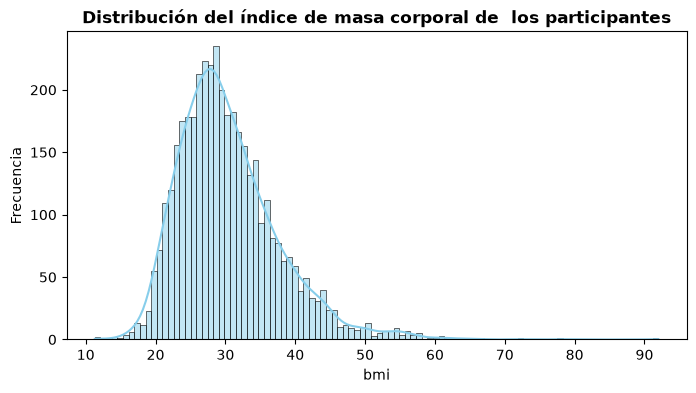

In [95]:
#gráfico para entender la distribución del indice de masa corporal de los adultos en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df_adultos["bmi"], bins=100, kde=True, color="skyblue")
plt.title("Distribución del índice de masa corporal de  los participantes", fontsize=12, fontweight="bold")
plt.xlabel("bmi", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

La variable bmi (Índice de Masa Corporal) muestra una distribución unimodal con una marcada asimetría positiva (sesgada a la derecha), concentrando la mayor densidad de participantes en el rango de 25 a 35 $\text{kg/m}^2$. (pico principal del histograma). Aunque la mayor parte de la muestra se sitúa en valores normopeso y sobrepeso/obesidad moderada, se observa una cola derecha bastante extendida que alcanza valores extremos por encima de 50 e incluso superando los 90 $\text{kg/m}^2$. Esta presencia de valores atípicos (outliers) acentuados sugiere la necesidad de evaluar su tratamiento o posible imputación mediante métricas robustas a la asimetría (como la mediana) antes del modelado predictivo.

In [96]:
# Presencia de valores nulos
n_nulos_bmi = df_adultos["bmi"].isna().sum()
pct_nulos_bmi = df_adultos["bmi"].isna().mean() * 100

print(f"Valores nulos en BMI: {n_nulos_bmi}")
print(f"Porcentaje de valores nulos en BMI: {pct_nulos_bmi:.2f}%")

Valores nulos en BMI: 181
Porcentaje de valores nulos en BMI: 4.25%


La variable índice de masa corporal (bmi) presentó 181 valores ausentes (4,3 % de la muestra adulta). Las estadísticas descriptivas y la representación gráfica de BMI se calcularon con los valores observados. La gestión de los valores faltantes se realizó posteriormente durante la fase de preprocesamiento del modelo.

<a id="variables-socioeconomicas"></a>
#### <a id="seccion-1-1-3"></a>Variables Socioeconómicas y Estilo de Vida

* smoking_status

In [97]:
df_adultos["smoking_status"].unique()

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [98]:
#tabla de frecuencias
tabla_smoking_status = pd.DataFrame({
    "Participantes adultos": df_adultos["smoking_status"].value_counts(),
    "Porcentaje (%)": (df_adultos["smoking_status"].value_counts(normalize=True) * 100).round(2)
})

tabla_smoking_status

,Participantes adultos,Porcentaje (%)
smoking_status,,
never smoked,1752,41.18
Unknown,862,20.26
formerly smoked,860,20.22
smokes,780,18.34


* ever_married

In [99]:
df_adultos["ever_married"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [ ]:
# Mapeo directo de Yes/No a 1/0
df_adultos["ever_married"] = df_adultos["ever_married"].map({"Yes": 1, "No": 0})

In [100]:
#tabla de frecuencias
tabla_ever_married = pd.DataFrame({
    "Participantes adultos": df_adultos["ever_married"].value_counts(),
    "Porcentaje (%)": (df_adultos["ever_married"].value_counts(normalize=True) * 100).round(2)
})

tabla_ever_married

,Participantes adultos,Porcentaje (%)
ever_married,,
Yes,3353,78.82
No,901,21.18


* work_type

In [101]:
# comprobamos que en el dataset original no hay adultos clasificados como "children" 
n_children = (df["work_type"] == "children").sum()
n_children_mayores_18 = ((df["work_type"] == "children") & (df["age"] >= 18)).sum()

print(f"Participantes clasificados como 'children': {n_children}")
print(f"Participantes 'children' con edad >= 18 años: {n_children_mayores_18}")
print(f"Edad máxima en la categoría 'children': {df.loc[df['work_type'] == 'children', 'age'].max()}")

Participantes clasificados como 'children': 687
Participantes 'children' con edad >= 18 años: 0
Edad máxima en la categoría 'children': 16.0


In [102]:
#comprobamos que en el dataset de adultos no hay categoría "children"
df_adultos["work_type"].unique()

<StringArray>
['Private', 'Self-employed', 'Govt_job', 'Never_worked']
Length: 4, dtype: str

In [103]:
#tabla de frecuencias
tabla_work_type = pd.DataFrame({
    "Participantes adultos": df_adultos["work_type"].value_counts(),
    "Porcentaje (%)": (df_adultos["work_type"].value_counts(normalize=True) * 100).round(2)
})

tabla_work_type

,Participantes adultos,Porcentaje (%)
work_type,,
Private,2791,65.61
Self-employed,807,18.97
Govt_job,651,15.30
Never_worked,5,0.12


* Residence_type

In [ ]:
# Ponemos el nombre de la columna en minuscula para normalizar 
df_adultos = df_adultos.rename(columns={"Residence_type": "residence_type"})

In [104]:
df_adultos["Residence_type"].unique()

<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str

In [105]:
#tabla de frecuencias
tabla_residence_type = pd.DataFrame({
    "Participantes adultos": df_adultos["Residence_type"].value_counts(),
    "Porcentaje (%)": (df_adultos["Residence_type"].value_counts(normalize=True) * 100).round(2)
})

tabla_residence_type

,Participantes adultos,Porcentaje (%)
Residence_type,,
Urban,2169,50.99
Rural,2085,49.01


<a id="variable-objetivo"></a>
#### <a id="seccion-1-1-4"></a>Variable Objetivo (`stroke`)

* stroke

In [106]:
df_adultos["stroke"].unique()

array([1, 0])

In [107]:
# Distribución de ictus en la muestra de adultos
print(df_adultos["stroke"].value_counts())
print("\nPorcentaje de ictus en adultos:")
print(df_adultos["stroke"].value_counts(normalize=True) * 100)

stroke
0    4007
1     247
Name: count, dtype: int64

Porcentaje de ictus en adultos:
stroke
0    94.1937
1     5.8063
Name: proportion, dtype: float64


In [108]:
#tabla de frecuencias
tabla_stroke = pd.DataFrame({
    "Participantes adultos": df_adultos["stroke"].value_counts(),
    "Porcentaje (%)": (df_adultos["stroke"].value_counts(normalize=True) * 100).round(2)
})

tabla_stroke

,Participantes adultos,Porcentaje (%)
stroke,,
0,4007,94.19
1,247,5.81


[🔝 Volver al índice](#indice)

<a id="analisis-bivariante"></a>
## 1.2 Análisis bivariante

### 1.1 Análisis Univariante

#### Variables Identificadoras y Demográficas
* **id:** Comprobación de duplicados y unicidad.
* **gender:** Frecuencias por género (y eliminación/tratamiento de valores residuales como 'Other' si los hay).
* **age:** Distribución de edad y filtrado de la población (mayores de 18 años).

#### Variables Clínicas y Estilo de Vida
* **hypertension & heart_disease:** Distribución de antecedentes médicos.
* **avg_glucose_level:** Distribución de glucosa en sangre (asimetría y rangos).
* **bmi:** Distribución del IMC y detección de $N$ valores faltantes ($X\%$).
* **smoking_status:** Frecuencia del hábito tabáquico y análisis de la categoría 'Unknown'.

#### Variables Socioeconómicas
* **ever_married, work_type, Residence_type:** Distribución de frecuencias categóricas.

#### Variable Objetivo
* **stroke:** Análisis de la proporción de clases (evidencia de desbalance de clases).